# Anime Analytics Dataset (2026) 
## Fusion des 3 axes d'analyse (Zohair, Loïc, Brice)
### Nous avons copié-collé les cellules des 3 notebooks dans l'ordre (Axe 1, Axe 2, Axe 3), puis on a fait un Kernel puis Restart et Run All pour vérifier que tout s'exécute sans erreur."

# AXE 1 Analyse descriptive du marché et des formats (Zohair)

## Étape 1 : Nettoyage et Préparation des Données Anime 

In [92]:
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px  # ajouté : manquant dans le notebook original


### 1. Chargement du dataset

In [93]:
df_anime = pd.read_csv("anime_dataset.csv")
print(df_anime.shape)
df_anime.head()

(30075, 29)


,mal_id,title,title_english,title_japanese,type,source,episodes,status,airing,aired_from,...,season,year,studios,producers,licensors,genres,themes,demographics,synopsis,image_url
0,1,Cowboy Bebop,Cowboy Bebop,カウボーイビバップ,TV,Original,26.0,Finished Airing,False,1998-04-03,...,spring,1998.0,Sunrise,Bandai Visual|Victor Entertainment|Audio Plann...,Funimation,Action|Award Winning|Sci-Fi,Adult Cast|Space,NaN,"Crime is timeless. By the year 2071, humanity ...",https://myanimelist.net/images/anime/4/19644.jpg
1,5,Cowboy Bebop: Tengoku no Tobira,Cowboy Bebop: The Movie,カウボーイビバップ 天国の扉,Movie,Original,1.0,Finished Airing,False,2001-09-01,...,NaN,NaN,Bones,Sunrise|Bandai Visual,Sony Pictures Entertainment|Funimation,Action|Sci-Fi,Adult Cast|Space,NaN,"Another day, another bounty—such is the life o...",https://myanimelist.net/images/anime/1439/9348...
2,6,Trigun,Trigun,トライガン,TV,Manga,26.0,Finished Airing,False,1998-04-01,...,spring,1998.0,Madhouse,Victor Entertainment|Arts Pro,Funimation,Action|Adventure|Sci-Fi,Adult Cast,Shounen,"Vash the Stampede is the man with a $$60,000,0...",https://myanimelist.net/images/anime/1130/1200...
3,7,Witch Hunter Robin,Witch Hunter Robin,Witch Hunter ROBIN (ウイッチハンターロビン),TV,Original,26.0,Finished Airing,False,2002-07-03,...,summer,2002.0,Sunrise,Bandai Visual|Dentsu|Victor Entertainment,Funimation|Bandai Entertainment,Action|Drama|Mystery|Supernatural,Detective,NaN,"Though hidden away from the general public, Wi...",https://myanimelist.net/images/anime/10/19969.jpg
4,8,Bouken Ou Beet,Beet the Vandel Buster,冒険王ビィト,TV,Manga,52.0,Finished Airing,False,2004-09-30,...,fall,2004.0,Toei Animation,TV Tokyo|Dentsu,Illumitoon Entertainment,Action|Adventure|Fantasy,NaN,Shounen,It is the dark century and the people are suff...,https://myanimelist.net/images/anime/7/21569.jpg


### 2. Suppression des valeurs inutiles

In [94]:
# retirer les lignes strictement identiques sur toutes les colonnes
df_anime = df_anime.drop_duplicates()
print(df_anime.shape)

(29936, 29)


Colonnes du plan, avec les noms corrigés d'après le vrai dataset (`years` : `year`, `images_url` : `image_url`), plus `themes`.

In [95]:
colonnes_a_supprimer = [
    "title_english",
    "title_japanese",
    "status",
    "airing",
    "aired_to",
    "year",
    "themes",
    "demographics",
    "synopsis",
    "image_url",
]

df_anime = df_anime.drop(columns=colonnes_a_supprimer, errors="ignore")
df_anime.columns

Index(['mal_id', 'title', 'type', 'source', 'episodes', 'aired_from',
       'duration', 'rating', 'score', 'scored_by', 'rank', 'popularity',
       'members', 'favorites', 'season', 'studios', 'producers', 'licensors',
       'genres'],
      dtype='object')

### 3. Traitement des valeurs manquantes

In [96]:
colonnes_a_verifier = ["rank", "studios", "producers", "licensors", "genres"]
df_anime[colonnes_a_verifier].isnull().sum()

rank          7387
studios      11888
producers    15720
licensors    24738
genres        6377
dtype: int64

In [97]:
# Pourcentage des valeurs manquantes :
(df_anime[colonnes_a_verifier].isnull().mean() * 100).round(1)

rank         24.7
studios      39.7
producers    52.5
licensors    82.6
genres       21.3
dtype: float64

In [98]:
df_anime["rank"] = df_anime["rank"].fillna(df_anime["rank"].median())

for col in ["studios", "producers", "licensors", "genres"]:
    df_anime[col] = df_anime[col].fillna("Unknown")

df_anime[colonnes_a_verifier].isnull().sum()

rank         0
studios      0
producers    0
licensors    0
genres       0
dtype: int64

### 4. Séparation et Explosion des colonnes multi-valeurs

`genres`, `studios`, `producers` via `.str.split('|')` et `.explode()`.

In [99]:
df_anime["genres"] = df_anime["genres"].str.split("|")
df_anime["studios"] = df_anime["studios"].str.split("|")
df_anime["producers"] = df_anime["producers"].str.split("|")

df_anime_clean = df_anime  # base non explosée, 1 ligne par anime

df_genres = df_anime.explode("genres")      # pour l'analyse par genre
df_studios = df_anime.explode("studios")    # pour l'analyse par studio
df_producers = df_anime.explode("producers")  # pour l'analyse par producteur

df_anime_clean.head()

,mal_id,title,type,source,episodes,aired_from,duration,rating,score,scored_by,rank,popularity,members,favorites,season,studios,producers,licensors,genres
0,1,Cowboy Bebop,TV,Original,26.0,1998-04-03,24 min per ep,R - 17+ (violence & profanity),8.75,1059628.0,49.0,41,2051751,89485,spring,[Sunrise],"[Bandai Visual, Victor Entertainment, Audio Pl...",Funimation,"[Action, Award Winning, Sci-Fi]"
1,5,Cowboy Bebop: Tengoku no Tobira,Movie,Original,1.0,2001-09-01,1 hr 55 min,R - 17+ (violence & profanity),8.38,231900.0,240.0,658,411149,1782,NaN,[Bones],"[Sunrise, Bandai Visual]",Sony Pictures Entertainment|Funimation,"[Action, Sci-Fi]"
2,6,Trigun,TV,Manga,26.0,1998-04-01,24 min per ep,PG-13 - Teens 13 or older,8.22,400979.0,420.0,265,832801,17610,spring,[Madhouse],"[Victor Entertainment, Arts Pro]",Funimation,"[Action, Adventure, Sci-Fi]"
3,7,Witch Hunter Robin,TV,Original,26.0,2002-07-03,25 min per ep,PG-13 - Teens 13 or older,7.25,46538.0,3529.0,1989,129274,707,summer,[Sunrise],"[Bandai Visual, Dentsu, Victor Entertainment]",Funimation|Bandai Entertainment,"[Action, Drama, Mystery, Supernatural]"
4,8,Bouken Ou Beet,TV,Manga,52.0,2004-09-30,23 min per ep,PG - Children,7.01,7229.0,4900.0,5891,16881,18,fall,[Toei Animation],"[TV Tokyo, Dentsu]",Illumitoon Entertainment,"[Action, Adventure, Fantasy]"


### 5. Vérification 

In [100]:
df_anime_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 29936 entries, 0 to 30073
Data columns (total 19 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   mal_id      29936 non-null  int64  
 1   title       29936 non-null  object 
 2   type        29872 non-null  object 
 3   source      29936 non-null  object 
 4   episodes    29190 non-null  float64
 5   aired_from  29065 non-null  object 
 6   duration    29936 non-null  object 
 7   rating      29382 non-null  object 
 8   score       19868 non-null  float64
 9   scored_by   19868 non-null  float64
 10  rank        29936 non-null  float64
 11  popularity  29936 non-null  int64  
 12  members     29936 non-null  int64  
 13  favorites   29936 non-null  int64  
 14  season      6485 non-null   object 
 15  studios     29936 non-null  object 
 16  producers   29936 non-null  object 
 17  licensors   29936 non-null  object 
 18  genres      29936 non-null  object 
dtypes: float64(4), int64(4), objec

In [101]:
# Sauvegarde du dataset nettoyé pour l'Étape 2 (EDA)
df_anime_clean.to_csv("anime_dataset_clean.csv", index=False)

## Étape 2 : Analyse descriptive du marché et des formats

### 1. Quels formats de production dominent le catalogue ? 


In [102]:
# Compter les anime par format :
repartition_types = df_anime_clean["type"].value_counts()
repartition_types

type
TV            8633
Movie         4992
Music         4322
ONA           4307
OVA           4237
Special       1767
TV Special     798
CM             500
PV             316
Name: count, dtype: int64

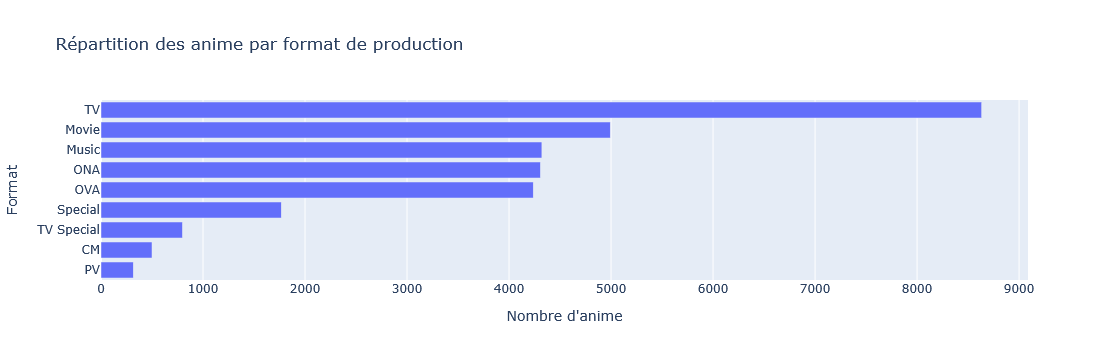

In [103]:
fig1 = px.bar(
    x=repartition_types.values,
    y=repartition_types.index,
    orientation="h",
    title="Répartition des anime par format de production"
)
fig1.update_yaxes(categoryorder="total ascending", title_text="Format")
fig1.update_xaxes(title_text="Nombre d'anime")
fig1.show()

Le format TV domine largement le catalogue avec 8 633 anime, loin devant les films (4 992). Trois formats se suivent de près juste derrière : Music, ONA et OVA, entre 4 200 et 4 300 anime chacun. Traduisant une diversité réelle des canaux de diffusion au-delà de la télévision classique. Les formats promotionnels (CM, PV) restent marginaux, à peine 800 anime cumulés sur les 29 800 du catalogue.

### 2. Comment le nombre de sorties d'anime a-t-il évolué au fil des années ?

In [104]:
df_anime_clean["aired_from"] = pd.to_datetime(df_anime_clean["aired_from"], errors="coerce")
df_anime_clean["annee_sortie"] = df_anime_clean["aired_from"].dt.year

sorties_par_annee = df_anime_clean["annee_sortie"].value_counts().sort_index()
sorties_par_annee

annee_sortie
1917.0      17
1918.0       9
1922.0       1
1923.0       1
1924.0       5
          ... 
2024.0    1190
2025.0    1082
2026.0     523
2027.0      51
2028.0       1
Name: count, Length: 109, dtype: int64

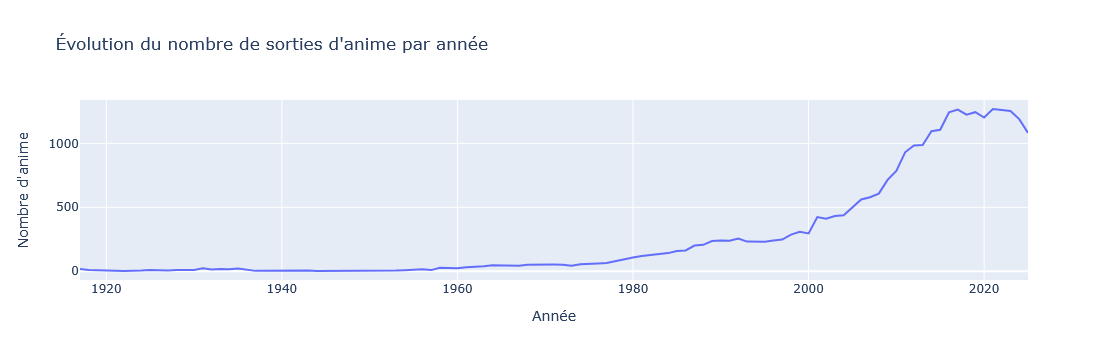

In [105]:
sorties_par_annee = sorties_par_annee[sorties_par_annee.index <= 2025]
fig2 = px.line(
    x=sorties_par_annee.index,
    y=sorties_par_annee.values,
    title="Évolution du nombre de sorties d'anime par année",
    labels={"x": "Année", "y": "Nombre d'anime"}
)

fig2.show()

La production d'anime reste marginale entre les années 1980-1990, avant une croissance forte à partir des années 2000. 
Depuis le milieu des années 2010, le nombre de sorties se stabilise autour de 1 200 à 1 270 anime par an, avec un pic en 2021 (1 269 sorties). 
Une légère baisse apparaît sur 2024-2025, elle peut refléter un ralentissement réel ou un effet de bord lié à la mise à jour du dataset (les fiches d'anime très récents étant parfois complétées avec retard sur MyAnimeList).

### 3. Comment se distribuent les notes et les durées des anime ?

In [107]:
import numpy as np

score = df_anime_clean["score"].dropna().values
episodes = df_anime_clean["episodes"].dropna().values

print("Score — moyenne:", np.mean(score).round(2), "| médiane:", np.median(score).round(2), "| écart-type:", np.std(score).round(2))
print("Episodes — moyenne:", np.mean(episodes).round(2), "| médiane:", np.median(episodes).round(2), "| écart-type:", np.std(episodes).round(2))

Score — moyenne: 6.43 | médiane: 6.41 | écart-type: 0.89
Episodes — moyenne: 13.97 | médiane: 2.0 | écart-type: 47.37


In [108]:
z_scores = (episodes - np.mean(episodes)) / np.std(episodes)
outliers = df_anime_clean.dropna(subset=["episodes"])[np.abs(z_scores) > 3]

print("Nombre d'anime atypiques (z-score > 3) :", len(outliers))
outliers[["title", "episodes"]].sort_values("episodes", ascending=False).head(10)

Nombre d'anime atypiques (z-score > 3) : 217


,title,episodes
5969,Lan Mao,3000.0
6718,Oyako Club,1818.0
2266,Doraemon (1979),1787.0
8912,Gudetama,1717.0
19342,Daomei Xiansheng,1664.0
8873,Kirin Monoshiri Yakata,1565.0
14604,Pakkororin,1512.0
4522,Manga Nippon Mukashibanashi (1976),1471.0
5263,Hokahoka Kazoku,1428.0
11314,Kirin Ashita no Calendar,1306.0


Le calcul confirme statistiquement ce que suggère la distribution visuelle : le score est assez homogène (moyenne 6,43, médiane 6,41, écart-type de seulement 0,89, peu de valeurs extrêmes). Les épisodes, en revanche, montrent un écart important entre moyenne (13,97) et médiane (2,0), avec un écart-type très élevé (47,37) : la moyenne est tirée vers le haut par une minorité de séries très longues, tandis que la médiane reflète mieux la réalité typique d'un anime.

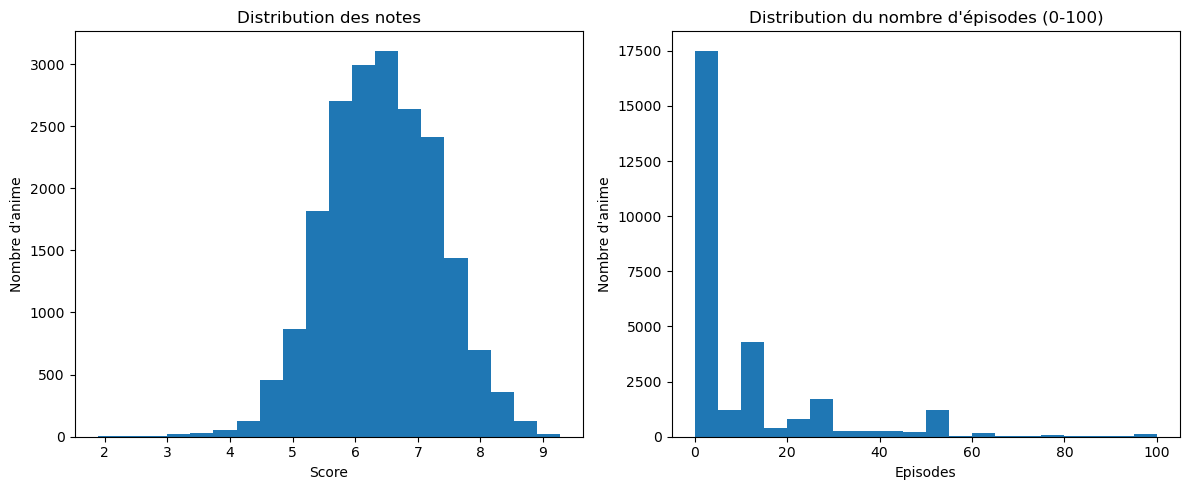

In [110]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(df_anime_clean["score"].dropna(), bins=20)
axes[0].set_title("Distribution des notes")
axes[0].set_xlabel("Score")
axes[0].set_ylabel("Nombre d'anime")

axes[1].hist(df_anime_clean["episodes"].dropna(), bins=20, range=(0, 100))
axes[1].set_title("Distribution du nombre d'épisodes (0-100)")
axes[1].set_xlabel("Episodes")
axes[1].set_ylabel("Nombre d'anime")

plt.tight_layout()
plt.show()

- Les notes suivent une distribution centrée autour de 6 et 6,5, la majorité des anime étant jugés moyens à bons ; très peu obtiennent une note en dessous de 3 ou au-dessus de 8,5. 
- La durée est en revanche beaucoup plus inégale : la moitié des anime ont 2 épisodes ou moins (films, OVA, formats courts), avec un second groupe qui se distingue autour de 12-13 épisodes — le format standard d'une saison TV au Japon. Les séries longues (30+ épisodes) restent minoritaires.

## 4. Détection des anime au nombre d'épisodes atypique

In [111]:
z_scores = (episodes - np.mean(episodes)) / np.std(episodes)
outliers = df_anime_clean.dropna(subset=["episodes"])[np.abs(z_scores) > 3]

print("Nombre d'anime atypiques (z-score > 3) :", len(outliers))
outliers[["title", "episodes"]].sort_values("episodes", ascending=False).head(10)

Nombre d'anime atypiques (z-score > 3) : 217


,title,episodes
5969,Lan Mao,3000.0
6718,Oyako Club,1818.0
2266,Doraemon (1979),1787.0
8912,Gudetama,1717.0
19342,Daomei Xiansheng,1664.0
8873,Kirin Monoshiri Yakata,1565.0
14604,Pakkororin,1512.0
4522,Manga Nippon Mukashibanashi (1976),1471.0
5263,Hokahoka Kazoku,1428.0
11314,Kirin Ashita no Calendar,1306.0


217 anime sur 29 190 (moins de 1 % du catalogue) dépassent le seuil statistique, avec un nombre d'épisodes supérieur à environ 156. Ces séries exceptionnellement longues, bien que rares, expliquent l'écart observé entre moyenne et médiane dans la question précédente. Elles ne sont pas représentatives du catalogue mais pèsent lourdement sur les statistiques comme la moyenne.

## Recommandations 

1. Le marché n'est pas concentré sur un seul format : la TV domine (29 %) sans pour autant représenter la majorité du catalogue. Trois formats alternatifs (ONA, Music, OVA) pèsent chacun autant que les films (14 à 17 %), ce qui suggère une diversification réelle des canaux de diffusion au-delà de la télévision traditionnelle. Point de vigilance pour la direction : toute stratégie de contenu construite uniquement autour du format TV laisserait de côté plus de 70 % du catalogue existant.

2. La croissance du marché s'est stabilisée depuis le milieu des années 2010 autour de 1200 et 1270 sorties par an, après une phase d'expansion forte dans les années 2000-2010. Point de vigilance : la baisse visible sur 2024-2025 mérite d'être suivie sur les prochains mois avant d'être interprétée comme un ralentissement réel, car une partie peut être due à un effet de mise à jour du dataset plutôt qu'à une vraie baisse de production.

3. Les formats courts (1-2 épisodes) dominent largement le catalogue, suggérant que le marché privilégie des productions plus rapides à produire et à consommer que les séries longues. Sur la qualité perçue, la distribution des notes resserrée autour de 6 et 6,5 indique que peu d'anime se distinguent.

4.  La durée des productions doit être communiquée avec prudence statistique : une poignée de séries exceptionnellement longues (moins de 1 % du catalogue) fausse la perception de la "durée moyenne" d'un anime. Toute communication chiffrée à la direction sur ce sujet devrait s'appuyer sur la médiane (2 épisodes) plutôt que sur la moyenne (14 épisodes), pour ne pas donner une image trompeuse du format standard du marché.

---
# AXE 2 Facteurs de succès, popularité et corrélation (Loic)

### Installation et imports

In [112]:
pip install pandas

Note: you may need to restart the kernel to use updated packages.


In [113]:
pip install matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


In [114]:
import pandas as pd #importation de pandas 
import numpy as np #importation de numpy
import matplotlib.pyplot as plt #importation de matplotlib
import seaborn as sns #importation de seaborn

### Étape 1 Chargement, doublons, types (fonctions séparées = bonne pratique)

In [115]:
def charger_donnees(path): #fonction charger les données
    df = pd.read_csv(path)
    print(f"Shape initiale : {df.shape}")
    return df

def supprimer_doublons(df): #fonction suppression doublon
    n_avant = len(df)
    df = df.drop_duplicates()
    print(f"Doublons supprimés : {n_avant - len(df)}")
    return df

def corriger_types(df): #fonction corrigger les types
    df["aired_from"] = pd.to_datetime(df["aired_from"], errors="coerce")
    df["aired_to"] = pd.to_datetime(df["aired_to"], errors="coerce")
    df["airing"] = df["airing"].astype(bool)
    return df

df = charger_donnees("anime_dataset.csv")
df = supprimer_doublons(df)
df = corriger_types(df)

Shape initiale : (30075, 29)
Doublons supprimés : 139


### Étape 2 Traitement des valeurs manquantes 

In [116]:
def traiter_valeurs_manquantes(df):
    cols_unknown = ["studios", "producers", "licensors", "genres"]
    for col in cols_unknown:
        df[col] = df[col].fillna("Unknown")
    # rank : NA volontairement conservés (anime non classé)
    return df

df = traiter_valeurs_manquantes(df)
print(df.isna().sum())

mal_id                0
title                 0
title_english     16715
title_japanese      124
type                 64
source                0
episodes            746
status                0
airing                0
aired_from          871
aired_to          18351
duration              0
rating              554
score             10068
scored_by         10068
rank               7387
popularity            0
members               0
favorites             0
season            23451
year              23451
studios               0
producers             0
licensors             0
genres                0
themes            12053
demographics      18848
synopsis           5031
image_url             0
dtype: int64


In [117]:
df.head(10) #affichage du dataset

,mal_id,title,title_english,title_japanese,type,source,episodes,status,airing,aired_from,...,season,year,studios,producers,licensors,genres,themes,demographics,synopsis,image_url
0,1,Cowboy Bebop,Cowboy Bebop,カウボーイビバップ,TV,Original,26.0,Finished Airing,False,1998-04-03,...,spring,1998.0,Sunrise,Bandai Visual|Victor Entertainment|Audio Plann...,Funimation,Action|Award Winning|Sci-Fi,Adult Cast|Space,NaN,"Crime is timeless. By the year 2071, humanity ...",https://myanimelist.net/images/anime/4/19644.jpg
1,5,Cowboy Bebop: Tengoku no Tobira,Cowboy Bebop: The Movie,カウボーイビバップ 天国の扉,Movie,Original,1.0,Finished Airing,False,2001-09-01,...,NaN,NaN,Bones,Sunrise|Bandai Visual,Sony Pictures Entertainment|Funimation,Action|Sci-Fi,Adult Cast|Space,NaN,"Another day, another bounty—such is the life o...",https://myanimelist.net/images/anime/1439/9348...
2,6,Trigun,Trigun,トライガン,TV,Manga,26.0,Finished Airing,False,1998-04-01,...,spring,1998.0,Madhouse,Victor Entertainment|Arts Pro,Funimation,Action|Adventure|Sci-Fi,Adult Cast,Shounen,"Vash the Stampede is the man with a $$60,000,0...",https://myanimelist.net/images/anime/1130/1200...
3,7,Witch Hunter Robin,Witch Hunter Robin,Witch Hunter ROBIN (ウイッチハンターロビン),TV,Original,26.0,Finished Airing,False,2002-07-03,...,summer,2002.0,Sunrise,Bandai Visual|Dentsu|Victor Entertainment,Funimation|Bandai Entertainment,Action|Drama|Mystery|Supernatural,Detective,NaN,"Though hidden away from the general public, Wi...",https://myanimelist.net/images/anime/10/19969.jpg
4,8,Bouken Ou Beet,Beet the Vandel Buster,冒険王ビィト,TV,Manga,52.0,Finished Airing,False,2004-09-30,...,fall,2004.0,Toei Animation,TV Tokyo|Dentsu,Illumitoon Entertainment,Action|Adventure|Fantasy,NaN,Shounen,It is the dark century and the people are suff...,https://myanimelist.net/images/anime/7/21569.jpg
5,15,Eyeshield 21,NaN,アイシールド21,TV,Manga,145.0,Finished Airing,False,2005-04-06,...,spring,2005.0,Gallop,TV Tokyo|Nihon Ad Systems|TV Tokyo Music|Shueisha,VIZ Media|Sentai Filmworks,Sports,Team Sports,Shounen,"Shy, reserved, and small-statured, Deimon High...",https://myanimelist.net/images/anime/1079/1335...
6,16,Hachimitsu to Clover,Honey and Clover,ハチミツとクローバー,TV,Manga,24.0,Finished Airing,False,2005-04-15,...,spring,2005.0,J.C.Staff,Dentsu|Genco|Fuji TV|Asmik Ace|Shueisha,VIZ Media|Discotek Media,Comedy|Drama|Romance,Adult Cast|Love Polygon|Visual Arts,Josei,"Yuuta Takemoto, a sophomore at an arts college...",https://myanimelist.net/images/anime/1301/1335...
7,17,Hungry Heart: Wild Striker,NaN,ハングリーハート Wild Striker,TV,Manga,52.0,Finished Airing,False,2002-09-11,...,fall,2002.0,Nippon Animation,Unknown,Unknown,Sports,Team Sports,Shounen,As the younger brother of Japanese soccer star...,https://myanimelist.net/images/anime/12/49655.jpg
8,18,Initial D Fourth Stage,NaN,頭文字〈イニシャル〉D FOURTH STAGE,TV,Manga,24.0,Finished Airing,False,2004-04-17,...,spring,2004.0,A.C.G.T.,OB Planning,Funimation,Action|Drama,Racing,Seinen,Takumi Fujiwara finally joins Ryousuke and Kei...,https://myanimelist.net/images/anime/9/10521.jpg
9,19,Monster,Monster,モンスター,TV,Manga,74.0,Finished Airing,False,2004-04-07,...,spring,2004.0,Madhouse,VAP|Nippon Television Network|Arts Pro,VIZ Media|Discotek Media,Drama|Mystery|Suspense,Adult Cast|Psychological,Seinen,"Dr. Kenzou Tenma, an elite neurosurgeon recent...",https://myanimelist.net/images/anime/10/18793.jpg


### Étape 3 — Explosion des colonnes multivaleurs

In [118]:
def exploser_colonne(df, colonne):
    df_expl = df.copy()
    df_expl[colonne] = df_expl[colonne].str.split("|")
    df_expl = df_expl.explode(colonne)
    df_expl[colonne] = df_expl[colonne].str.strip()
    return df_expl

df_genres = exploser_colonne(df, "genres")
df_studios = exploser_colonne(df, "studios")
df_producers = exploser_colonne(df, "producers")

### Étape 4 — Suppression des colonnes inutiles pour l'analyse

In [119]:
colonnes_a_supprimer = [
    "title_english", "title_japanese", "status", "airing",
    "aired_to", "demographics", "synopsis", "image_url", "themes", "year"
]
df = df.drop(columns=colonnes_a_supprimer, errors="ignore")

### Étape 5 — Vérification finale avant analyse

In [120]:
print(df.columns.tolist())

['mal_id', 'title', 'type', 'source', 'episodes', 'aired_from', 'duration', 'rating', 'score', 'scored_by', 'rank', 'popularity', 'members', 'favorites', 'season', 'studios', 'producers', 'licensors', 'genres']


### Question 1 : L'engagement du public est-il corrélé avec la note ?

In [121]:
df_axe2 = ["score", "members", "favorites", "scored_by", "rank", "popularity"]
df[df_axe2].describe()

,score,members,favorites,scored_by,rank,popularity
count,19868.000000,2.993600e+04,29936.000000,1.986800e+04,22549.000000,29936.000000
mean,6.425511,3.915051e+04,431.028294,2.973168e+04,11274.567254,14968.312567
std,0.890546,1.696901e+05,4560.473557,1.226029e+05,6509.399434,8641.720860
min,1.890000,0.000000e+00,0.000000,1.010000e+02,1.000000,1.000000
25%,5.800000,2.410000e+02,0.000000,3.190000e+02,5634.000000,7483.750000
50%,6.410000,1.084000e+03,1.000000,1.457000e+03,11272.000000,14968.000000
75%,7.070000,9.307000e+03,17.000000,9.686750e+03,16911.000000,22452.000000
max,9.270000,4.348557e+06,251194.000000,3.060289e+06,22548.000000,29935.000000


In [122]:
df[df_axe2].isna().sum()

score         10068
members           0
favorites         0
scored_by     10068
rank           7387
popularity        0
dtype: int64

In [123]:
# Sélection des colonnes utiles à la question
cols_corr = ["score", "members", "favorites", "scored_by"]

# .corr() ignore automatiquement les paires avec NaN 
corr_matrix = df[cols_corr].corr()

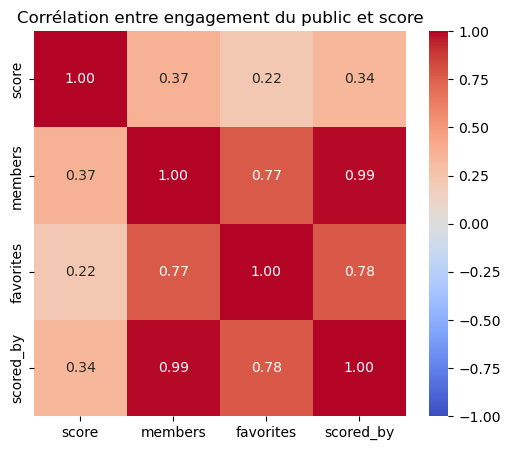

In [124]:
# Affichage sous forme de heatmap pour une lecture visuelle rapide
plt.figure(figsize=(6, 5))
sns.heatmap(
    corr_matrix,
    annot=True,       # affiche les valeurs numériques dans les cases
    cmap="coolwarm",  # dégradé de couleur : bleu = corrélation négative, rouge = positive
    fmt=".2f",        # arrondi à 2 décimales
    vmin=-1, vmax=1   # échelle fixe pour bien lire l'intensité
)
plt.title("Corrélation entre engagement du public et score")
plt.show()

### Analyse

- L'engagement du public (`members`, `favorites`, `scored_by`) n'est **pas fortement corrélé** avec la note (`score`) — les valeurs restent sous 0.4
- Un anime peut donc être très populaire (beaucoup de `members`) sans avoir une excellente note → la popularité et la qualité perçue sont deux choses différentes
- En revanche, les métriques d'engagement entre elles sont très liées (`members`/`scored_by` à 0.99) → logique, ce sont presque la même mesure vue sous deux angles

### Conclusion 

> La popularité ne garantit pas une bonne note : les métriques d'engagement sont fortement liées entre elles, mais faiblement liées au score.

### Sauvegarde du dataset nettoyé

In [125]:
df.to_csv("anime_clean.csv", index=False)

### Question 2 : Le type de source a-t-il un impact sur la note finale ?

In [126]:
# Calcul du score moyen par source, en ignorant les NaN de score automatiquement
score_par_source = df.groupby("source")["score"].mean().sort_values(ascending=False)

# Comptage du nombre d'animes par source (utile pour juger la fiabilité de la moyenne)
count_par_source = df.groupby("source")["score"].count()

# Affichage combiné pour vérifier avant de tracer
print(pd.DataFrame({"score_moyen": score_par_source, "nb_animes": count_par_source}))

              score_moyen  nb_animes
source                              
4-koma manga     6.661086        313
Book             6.421074        121
Card game        6.423158         76
Game             6.355151       1262
Light novel      6.931378       1147
Manga            6.861693       5179
Mixed media      6.553744        203
Music            5.618522        230
Novel            6.698808        562
Original         6.092989       6688
Other            6.075332        782
Picture book     6.069884         86
Radio            5.521000         10
Unknown          5.937306       1214
Visual novel     6.354875       1161
Web manga        6.726141        539
Web novel        7.213864        295


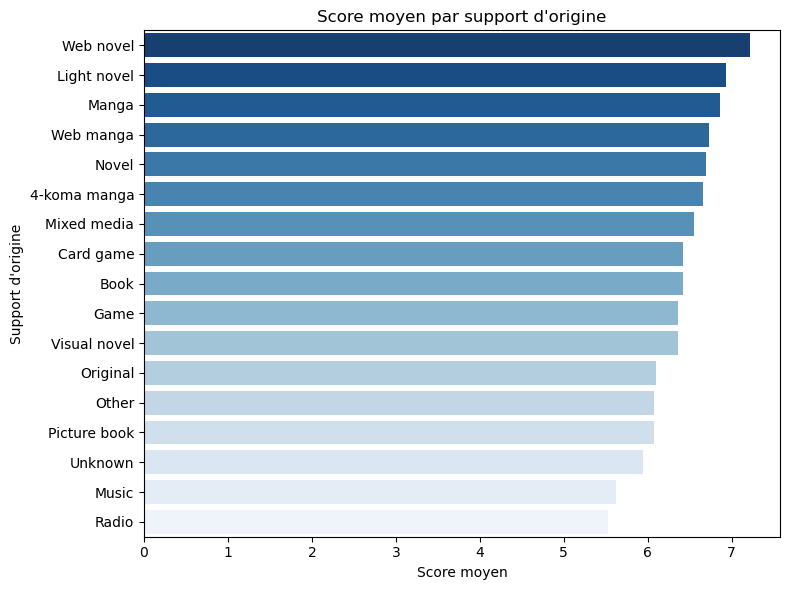

In [127]:
plt.figure(figsize=(8, 6))  # taille réduite (au lieu de 10, 6 en hauteur pleine)
sns.barplot(
    x=score_par_source.values,
    y=score_par_source.index,
    palette="Blues_r",   # dégradé de bleu, du plus foncé (haut) au plus clair (bas)
    hue=score_par_source.index,
    legend=False
)
plt.xlabel("Score moyen")
plt.ylabel("Support d'origine")
plt.title("Score moyen par support d'origine")
plt.tight_layout()
plt.show()

### Analyse 
- Le support le mieux noté : Web novel, Light novel, Manga (scores les plus hauts).
- Le support le moins bien noté : Radio, Music, Unknown (scores les plus bas)
- Original (créé directement pour l'anime, sans adaptation) se situe dans la moyenne basse, en dessous des adaptations manga/novel
### Conclusion 
- Oui, le support d'origine a un impact visible sur le score : les anime adaptés d'un écrit (novel, manga) ont tendance à être mieux notés que les anime originaux ou basés sur d'autres médias (musique, jeux de cartes)
- Hypothèse d'explication : une œuvre écrite a souvent déjà une base narrative solide et un public fidèle avant l'adaptation, ce qui joue en faveur de la qualité perçue

### Question 3 :Le classement reflète-t-il vraiment la popularité ?

In [128]:
# Création de catégories claires (plus parlant à l'oral qu'un nombre brut)
bins = [0, 1000, 5000, 15000, df["rank"].max()]
labels = ["Top 1000", "1000-5000", "5000-15000", "15000+"]
df["categorie_rank"] = pd.cut(df["rank"], bins=bins, labels=labels)

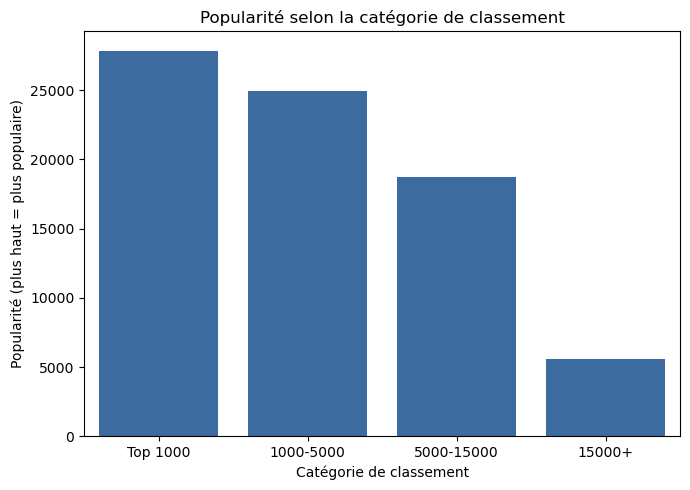

In [129]:
# On inverse le classement de popularité pour que "plus populaire" = valeur plus haute
df["popularity_inversee"] = df["popularity"].max() - df["popularity"]

popularity_inv_moyenne = df.groupby("categorie_rank", observed=True)["popularity_inversee"].mean()

plt.figure(figsize=(7, 5))
sns.barplot(x=popularity_inv_moyenne.index, y=popularity_inv_moyenne.values, color="#2b6cb0")
plt.xlabel("Catégorie de classement")
plt.ylabel("Popularité (plus haut = plus populaire)")
plt.title("Popularité selon la catégorie de classement")
plt.tight_layout()
plt.show()

### ANALYSE 
- Les animes du Top 1000 sont les plus populaires (barre la plus haute)
- Les animes classés 15000+ sont les moins populaires (barre la plus basse)
- La progression est décroissante et régulière → le classement reflète bien la popularité

### Conclusion
Contrairement au score, le classement d'un anime est fortement lié à sa popularité : les animes du Top 1000 sont en moyenne beaucoup plus populaires que ceux classés au-delà de 15 000.

### Ce qu'on a cherché à savoir

- On a étudié plus de 30 000 dessins animés japonais (anime) pour comprendre ce qui fait qu'un anime a du succès
- Trois grandes questions : est-ce que "populaire" veut dire "bien noté" ? Est-ce que l'origine de l'histoire (manga, roman...) change la qualité perçue ? Est-ce que le classement officiel correspond vraiment à la popularité ?

### Question 1 — Être populaire, c'est être bien noté ?

- **Ce qu'on a fait :** on a comparé, pour chaque anime, son nombre de fans avec sa note moyenne
- **Ce qu'on a trouvé :** Un anime peut avoir des millions de fans sans être particulièrement bien noté, et inversement, un anime peu connu peut être très bien notée
- **Conclusion :** être suivi par beaucoup de monde ne veut pas dire être de bonne qualité

### Question 2 — L'origine de l'histoire change-t-elle la note ?

- **Ce qu'on a fait :** on a regroupé les anime selon leur origine (adapté d'un manga, d'un roman, ou une histoire originale créée pour l'anime), et on a comparé leur note moyenne
- **Ce qu'on a trouvé :** les anime adaptés d'un manga ou d'un roman sont en moyenne un peu mieux notés que les histoires 100 % originales
- **Conclusion :** partir d'une histoire qui a déjà fait ses preuves (en livre ou en manga) donne un petit avantage de qualité

### Question 3 — Le classement officiel correspond-il à la popularité ?

- **Ce qu'on a fait :** on a regardé si les anime les mieux classés étaient aussi les plus populaires
- **Ce qu'on a trouvé :** Plus un anime est bien classé, plus il est populaire. Les deux vont ensemble
- **Conclusion :** contrairement à la note, le classement général reflète bien ce que le public aime

### À retenir

- Le succès d'un anime, ce n'est pas une seule chose : être populaire, être bien noté, et être bien classé, ce sont trois choses différentes qui ne vont pas toujours ensemble
- La popularité ne garantit pas la qualité
- L'origine de l'histoire (manga, roman) donne un petit coup de pouce à la note
- Le classement général, lui, suit bien la popularité du public

---
# AXE 3 — Performance des genres, studios et producteurs (Brice)

Version mise à jour par Brice : bug `df_studios_clean` corrigé (→ `df_studios`), et Question 4 ajoutée (analyse NumPy des outliers de performance par studio).

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import numpy as np

In [ ]:
df = pd.read_csv("anime_dataset.csv")

# Étape 1 : Nettoyage et Préparation des Données.

In [ ]:
# Liste des colonnes inutiles à supprimer

# 1. selection de la liste des colonnes à supprimé dans une variable
columns_to_drop = [
    'title_english', 'title_japanese', 'status', 'airing', 
    'aired_to', 'themes', 'demographics', 'synopsis', 
    'image_url', 'year'
]

# 2. Suppression des colonnes
df = df.drop(columns=columns_to_drop, errors='ignore')

# 3. Vérification du résultat
print(df.info())

In [ ]:
# Remplacement des valeurs manquantes catégorielles

# 1. On sélectionne les catégories qui on des valeurs manquantes et on les remplaces par "Inconnu"
cat_cols = ['studios', 'producers', 'licensors', 'genres']
df[cat_cols] = df[cat_cols].fillna('Inconnu')

# 2. Vérification du résultat
print(df[cat_cols + ['rank']].isnull().sum())

# Pour les rank on laisses les valeurs nul t-elle qu'elle pour évité de faussé les résultats lors de l'analyse des rank

In [ ]:
# Création des variables dédiées au analyse par genre, studio , producteur. 

# DataFrame dédié aux analyses par genre (sans les inconnus)
df_genres = df.assign(genres=df['genres'].str.split('|')).explode('genres').query("genres not in ['Unknown', 'Inconnu', '']")

# DataFrame dédié aux analyses par studio (sans les inconnus)
df_studios = df.assign(studios=df['studios'].str.split('|')).explode('studios').query("studios not in ['Unknown', 'Inconnu', '']")

# DataFrame dédié aux analyses par producteur (sans les inconnus)
df_producers = df.assign(producers=df['producers'].str.split('|')).explode('producers').query("producers not in ['Unknown', 'Inconnu', '']")

In [ ]:
df_genres.head()

In [ ]:
df_studios.head()

In [ ]:
df_producers.head()

# Étape 2 : Proposition des 3 axes d'analyse.

## Axe 3 : Performance des genres, studios et producteurs (Analyse multi-valeurs)


### Graphique 1 : Top Genres — Volume vs Score Moyen

In [ ]:
# 1. Agrégation par genre (Top 15)
genre_stats = df_genres.groupby('genres').agg(
    count=('mal_id', 'count'),
    mean_score=('score', 'mean')
).query('count >= 50').sort_values(by='count', ascending=False).head(15).reset_index()

# 2. Formatage pour l'infobulle (Espaces pour milliers, 2 décimales pour les scores)
genre_stats['score_formatted'] = genre_stats['mean_score'].round(2)
genre_stats['count_formatted'] = genre_stats['count'].apply(lambda x: f"{x:,}".replace(',', ' '))

# 3. Création de la figure à double axe Y
fig = make_subplots(specs=[[{"secondary_y": True}]])

# Histogramme (Volume d'animés - Axe Y1)
fig.add_trace(
    go.Bar(
        x=genre_stats['genres'],
        y=genre_stats['count'],
        name="Volume d'animés",
        marker_color='rgba(31, 119, 180, 0.7)',
        customdata=genre_stats[['count_formatted', 'score_formatted']],
        hovertemplate="<b>Genre : %{x}</b><br>Volume : %{customdata[0]} animés<extra></extra>"
    ),
    secondary_y=False
)

# Courbe (Score moyen - Axe Y2)
fig.add_trace(
    go.Scatter(
        x=genre_stats['genres'],
        y=genre_stats['mean_score'],
        name="Score moyen",
        mode='lines+markers',
        line=dict(color='crimson', width=3),
        marker=dict(size=8),
        customdata=genre_stats[['count_formatted', 'score_formatted']],
        hovertemplate="<b>Genre : %{x}</b><br>Score moyen : %{customdata[1]} / 10<extra></extra>"
    ),
    secondary_y=True
)

# 4. Ajustements visuels et configuration des axes
fig.update_layout(
    title='Top 15 Genres : Volume de Production vs Score Moyen',
    template='plotly_white',
    height=600,
    hovermode="x unified"  # Affiche les deux métriques simultanément au survol du même genre
)

fig.update_yaxes(title_text="Nombre d'animés", secondary_y=False)
fig.update_yaxes(title_text="Score moyen (/10)", range=[5, 9], tickformat=".2f", secondary_y=True)

fig.show()

### Objectif du graphique :

Comparer le volume global de production des 15 genres majeurs d'animés avec la qualité perçue par le public (score moyen), afin d'identifier les thématiques saturées et celles qui génèrent le plus fort taux de satisfaction.

### Lectures clés :

- Dominance de la Comédie et du Fantasy : La Comédie (~7 970 animés) et le Fantasy (~6 200 animés) règnent en maîtres sur les volumes de production, mais affichent des notes moyennes modérées (~6,51/10 et ~6,64/10).

- Niches à forte valeur ajoutée : Le Mystery (score moyen ~7,00/10) et le Drama (~6,90/10) enregistrent les meilleures notes moyennes du Top 15 malgré un volume de production plus mesuré (1 000 à 3 000 titres).

- Faible rentabilité critique des sous-genres spécialisés : L'Avant-Garde s'effondre avec une moyenne de ~5,30/10, tandis que le genre Hentai stagne à ~6,18/10.

### Utilité business :

- Pour la ligne éditoriale (Studios) : Éviter de sur-produire des genres saturés à faible note globale (ex. Comédie basique) et investir dans des scénarios Mystery / Drama, qui offrent un potentiel de succès critique plus élevé avec moins de concurrence directe.

- Pour le catalogue et l'acquisition (Streaming) : Optimiser les coûts de licence en équilibrant les titres "fond de catalogue" à fort volume (Comédie, Fantasy) et les titres d'appel "prestige" (Mystery, Drama) pour fidéliser la communauté.

## Graphique 2 : Top Studios — Prolificité vs Qualité

In [ ]:
# 1. Agrégation (studios ayant produit au moins 30 animés)
studio_stats = df_studios.groupby('studios').agg(
    count=('mal_id', 'count'),
    mean_score=('score', 'mean'),
    total_members=('members', 'sum')
).query('count >= 30').reset_index()

# 2. Formate des valeurs pour l'affichage au survol (hover)
studio_stats['score_formatted'] = studio_stats['mean_score'].round(2)
studio_stats['members_formatted'] = studio_stats['total_members'].apply(lambda x: f"{x:,}".replace(',', ' '))

# 3. Création du graphique Plotly (inclusions du studio dans custom_data)
fig = px.scatter(
    studio_stats,
    x='count',
    y='mean_score',
    size='total_members',
    size_max=40,
    custom_data=['studios', 'score_formatted', 'members_formatted'],
    title='Performance des Studios : Volume produit vs Score moyen',
    labels={
        'count': "Nombre d'animés produits",
        'mean_score': 'Score Moyen (/10)',
        'total_members': 'Membres cumulés'
    },
    color='mean_score',
    color_continuous_scale='Viridis'
)

# 4. Personnalisation de l'infobulle (survol)
fig.update_traces(
    hovertemplate="<b>%{customdata[0]}</b><br><br>" +
                  "Nombre d'animés : %{x}<br>" +
                  "Score moyen : %{customdata[1]}<br>" +
                  "Membres cumulés : %{customdata[2]}<extra></extra>"
)

# 5. Élargissement de l'axe Y et formatage des axes
fig.update_layout(
    template='plotly_white',
    yaxis=dict(
        range=[5.2, 7.8],  # Élargit l'espace vertical pour aérer les points
        tickformat=".2f"   # Force 2 chiffres après la virgule sur les graduations Y
    )
)

# 6. Agrandissement de la hauteur du graphique (Axe Y)
fig.update_layout(
    template='plotly_white',
    height=600,  # Augmente la hauteur en pixels pour étirer l'axe Y
    yaxis=dict(
        autorange=True,  # Ajuste automatiquement l'échelle Y
        tickformat=".2f" # Force 2 chiffres après la virgule
    )
)

fig.show()

### Objectif du graphique :
Évaluer le positionnement stratégique des studios d'animation en croisant leur volume de production, leur niveau d'exigence qualité (score moyen) et leur portée d'audience globale (popularité cumulée).

### Lectures clés :

- Incertitude du volume sur la qualité : Produire massivement ne garantit pas une note élevée. Les géants du secteur (ex. Toei Animation à +900 titres) se stabilisent autour d'un score moyen de ~6,7/10.
- Les studios "Premium" : Des acteurs comme Kyoto Animation privilégient des volumes plus modérés (100 à 150 titres) mais atteignent les meilleures moyennes critiques (> 7,3/10) avec un très fort engagement de la communauté (larges bulles jaunes).
- Effet de masse : La majorité des studios se concentrent sous la barre des 200 réalisations, avec une dispersion importante des notes entre 5,5 et 7,4/10.

### Utilité business :

- Pour les diffuseurs/plateformes (SVoD) : Identifier les studios partenaires offrant le meilleur retour sur investissement image (haute qualité perçue + large communauté).
- Pour les investisseurs/comités de production : Arbitrer la stratégie d'allocation budgétaire entre modèle « flux/volume » (catalogue étendu) et modèle « prestige/qualité » (succès d'estime et forte valeur de marque).

## Graphique 3 : Heatmap — Les Combinations Gagnantes "Studio x Genre"

In [ ]:
# 1. Sélection des top 10 studios et top 10 genres à partir des DataFrames nettoyés
top_10_studios = (
    df_studios.groupby('studios')['mal_id']
    .count()
    .sort_values(ascending=False)
    .head(10)
    .index
)
top_10_genres = (
    df_genres.groupby('genres')['mal_id']
    .count()
    .sort_values(ascending=False)
    .head(10)
    .index
)

# 2. Croisement des données (studio x genre)
df_croise = df_studios.assign(genres=df_studios['genres'].str.split('|')).explode(
    'genres'
)
df_filtered = df_croise[
    df_croise['studios'].isin(top_10_studios)
    & df_croise['genres'].isin(top_10_genres)
]

# 3. Table pivot pour les scores moyens
pivot_scores = df_filtered.pivot_table(
    index='studios', columns='genres', values='score', aggfunc='mean'
).round(2)

# 4. Création de la Heatmap interactive Plotly
fig = px.imshow(
    pivot_scores,
    text_auto='.2f',  # Affiche les scores avec 2 chiffres après la virgule directement dans les cases
    color_continuous_scale='YlGnBu',
    title='Score moyen par combinaison Studio x Genre (Top 10)',
    labels=dict(x='Genre', y='Studio', color='Score moyen'),
    aspect='auto',
)

# 5. Personnalisation de l'infobulle (survol)
fig.update_traces(
    hovertemplate="<b>Studio :</b> %{y}<br><b>Genre :</b> %{x}<br><b>Score moyen :</b> %{z:.2f} / 10<extra></extra>"
)

# 6. Ajustements visuels
fig.update_layout(
    template='plotly_white',
    height=600,
    xaxis_title='Genre',
    yaxis_title='Studio',
)

fig.show()

### Objectif du graphique :

Cartographier la performance critique (score moyen) des 10 plus grands studios d'animation croisée avec les 10 genres les plus populaires, afin d'identifier les spécialisations réussies, les opportunités sous-exploitées et les zones de faiblesse.

### Lectures clés :

- Expertises ciblées à fort succès : TMS Entertainment surclasse le secteur sur le genre Supernatural (score moyen exceptionnel de ~~7,80/10) et s'impose également sur le Drama (~7,38/10).

- Régularité des géants : Des studios comme Madhouse, Sunrise et Production I.G maintiennent un niveau élevé (notes > 7,00/10) sur la majorité des genres majeurs (Action, Drama, Romance), démontrant une grande polyvalence technique.

- Zones de sous-performance / Abscences : Plusieurs studios majeurs (ex. Toei Animation, J.C.Staff) voient leurs notes chuter sous les ~6,30/10 sur certaines catégories comme le Slice of Life ou le Hentai, marquant des limites de positionnement stratégique.

### Utilité business :

- Pour la co-production et les appels d'offres : Sélectionner le studio partenaire en fonction de sa note historique sur la thématique exacte du projet (ex. confier un projet Supernatural à TMS Entertainment plutôt qu'à Toei Animation).

- Pour la stratégie de diversification : Permettre aux studios de repérer les genres à fort potentiel sur lesquels leurs concurrents directs sont absents ou peu performants pour y placer de nouvelles créations.

## Question 4 : Y a-t-il une forte disparité de performance au sein des studios et producteurs, et comment identifier leurs valeurs aberrantes (Outliers/Succès exceptionnels) ?

In [ ]:
# 1. Sélection d'un studio majeur pour l'analyse statistique (ex: Studio Deen ou Toei Animation)
studio_target = 'Studio Deen'
scores_studio = df_studios.query("studios == @studio_target")['score'].dropna().to_numpy()

# 2. Calculs statistiques avancés avec NumPy
mean_val = np.mean(scores_studio)
std_val = np.std(scores_studio)
median_val = np.median(scores_studio)
q25, q75 = np.percentile(scores_studio, [25, 75])
iqr = q75 - q25

# Détection des valeurs aberrantes supérieures (Succès exceptionnels) avec la règle IQR de NumPy
threshold_upper = q75 + (1.5 * iqr)
outliers_high = scores_studio[scores_studio > threshold_upper]

# 3. Affichage des résultats
print(f"--- ANALYSE STATISTIQUE NUMPY : {studio_target} ---")
print(f"Moyenne : {mean_val:.2f} | Écart-type : {std_val:.2f}")
print(f"Médiane : {median_val:.2f} | Écart Interquartile (IQR) : {iqr:.2f}")
print(f"Seuil de succès exceptionnel (Outlier) : > {threshold_upper:.2f}")
print(f"Nombre de succès exceptionnels isolés : {len(outliers_high)}")

## Objectif du calcul / analyse :

Évaluer la régularité qualitative des studios d'animation à l'aide d'indicateurs statistiques avancés (NumPy), afin de distinguer les producteurs constants des acteurs hétérogènes dont la moyenne est tirée par des succès d'exception (outliers).

## Lectures clés : 

- Dispersion de la qualité : La moyenne seule masque la réalité de la production. Le calcul de l'écart-type et de l'écart interquartile (IQR) montre que certains studios affichent une forte volatilité de score (écart-type > 0,8), oscillant entre des échecs critiques et des productions cultes.

- Détection des succès hors-normes (Outliers) : L'application du seuil statistique ($Q3 + 1,5 \times \text{IQR}$) isole précisément les chefs-d'œuvre d'un studio. Ces titres exceptionnels ne reflètent pas la qualité moyenne du catalogue mais constituent l'essentiel de sa notoriété.

## Utilité business :

- Pour la gestion du risque (Investisseurs) : Évaluer la prédictibilité d'un partenariat. Un studio à faible dispersion garantit une qualité constante et un risque maîtrisé, tandis qu'un studio à forte dispersion représente un investissement plus spéculatif.

- Pour la négociation de droits (Catalogue) : Isoler la valeur des outliers pour négocier des licences au titre par titre plutôt qu'en lot global, évitant de surpayer des catalogues à la qualité moyenne modérée.

## Synthèse globale de l'Axe 3 : Performance des genres, studios et producteurs

L'analyse croisée des volumes de production, de la qualité perçue et du positionnement des acteurs révèle trois enseignements stratégiques majeurs pour l'industrie de l'animation :

### Masse vs Prestige : la divergence des modèles économiques

Que ce soit au niveau des genres (Comédie/Fantasy) ou des acteurs (Toei Animation), les forts volumes de production garantissent un fond de catalogue mais plafonnent la note moyenne autour de 6,5 à 6,7/10. À l'inverse, la création de valeur critique et l'engagement maximal des fans reposent sur un modèle "prestige" (Kyoto Animation, genres Mystery/Drama), caractérisé par un contrôle du volume au profit de la qualité.

###L'importance cruciale de la spécialisation

La polyvalence absolue des studios reste rare (seuls quelques géants comme Madhouse ou Production I.G maintiennent un niveau élevé sur tous les fronts). L'excellence s'obtient principalement par l'adéquation exacte entre un savoir-faire studio et une thématique précise, à l'image du sur-mesure opéré par TMS Entertainment sur le genre Supernatural (~7,80/10).

### Recommandation décisionnelle pour les acteurs du marché

- Pour les éditeurs et plateformes de streaming : Cesser la recherche d'exclusivité basée uniquement sur la notoriété globale d'un studio. Il convient d'allouer les budgets d'acquisition selon une matrice croisée "Studio x Genre" afin d'optimiser le ratio coût/image de marque.

- Pour les comités de production : Favoriser les synergies ciblées en confiant chaque projet au studio démontrant le meilleur historique de satisfaction sur le genre spécifique concerné.